<a href="https://colab.research.google.com/github/romoliangelica314/Fraud_Detection_ML_Project/blob/main/Fraud_Dataset_MLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction:

This ML project deals with a binary classification problem in the context of car insurance fraud detection\.


The dataset used contains insurance records which describe policy holders, reported accidents, and claim characteristics, with a target variable which indicates whether the claim was labelled as fraudulent or not\.

Some of the most relevant features include:

- policy information, such as deductibles and claim amounts  
- insured person's characteristics, such as age and education level  
- accident details, for example time of occurrence or the number of vehicles involved

The dataset can be found from the following source:

https://www.kaggle.com/datasets/ahluwaliasaksham/car-insurance-fraud-detection-dataset

The goal is to build and evaluate a supervised learning pipeline that predicts fraudulent claims, following the modelling approach used in the course\.

## Importing necessary libraries:

In [55]:
import pandas as pd
import numpy as np
import itertools

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix,
classification_report, precision_recall_curve, balanced_accuracy_score, PrecisionRecallDisplay)

from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
RandomizedSearchCV, cross_validate, learning_curve, validation_curve, cross_val_score, cross_val_predict)

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (FunctionTransformer, RobustScaler, StandardScaler,
OneHotEncoder, OrdinalEncoder)

from sklearn.decomposition import PCA
from scipy.stats import loguniform

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as IMBPipeline

import missingno as msno
import matplotlib.pyplot as plt
import warnings
import seaborn as sns


warnings.filterwarnings('ignore')

In [56]:
!find /content -name "fraud_dataset.csv"

/content/sample_data/fraud_dataset.csv


## Dataset overview:

The dataset contains 13 760 claim records with 24 features\.

The class distribution is moderately imbalanced; fraudulent claims are a minority of the data\.

Before any preprocessing or injection of missing values, we first examine the original dataset's \('dfAnalyse'\) structure, data types, and target distribution\.

In [57]:
dfOriginal = pd.read_csv('/content/sample_data/fraud_dataset.csv')
dfAnalyse = dfOriginal.copy()
df = dfAnalyse.copy()

In [58]:
#The target variable which indicates whether a claim was fraudulent
targetColumn = 'fraud_reported'

To visualize class imbalance in the target variable, counts and percentages are plotted:

,Count,Percentage
fraud_reported,,
N,10320,75.0
Y,3440,25.0


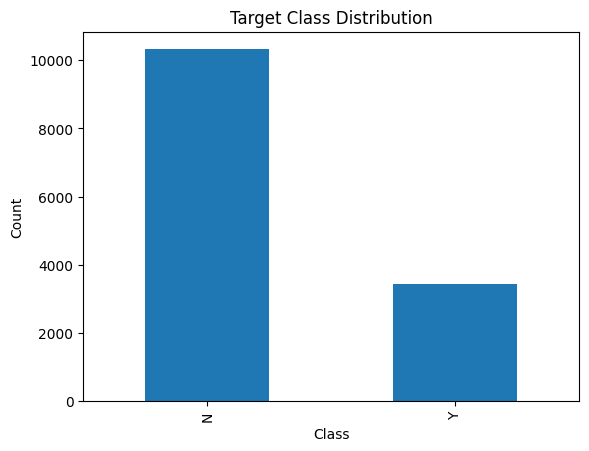

In [59]:
targetCounts = dfAnalyse[targetColumn].value_counts(dropna=False)
targetPercentage = (dfAnalyse[targetColumn].value_counts(normalize=True,
dropna=False).mul(100).round(1))

imbalanceTable = pd.DataFrame({
    "Count": targetCounts,
    "Percentage": targetPercentage})

display(imbalanceTable)

ax = dfAnalyse[targetColumn].value_counts().plot(kind="bar")
ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

In [60]:
#Data types to guide preprocessing choices
print("\nData types:")
display(dfAnalyse.dtypes)


Data types:


,0
policy_id,object
policy_state,object
policy_deductible,int64
policy_annual_premium,float64
insured_age,int64
insured_sex,object
insured_education_level,object
insured_occupation,object
insured_hobbies,object
incident_date,object


In [61]:
#Check for duplicates to avoid repeated data (which would create bias)
nDup = dfAnalyse.duplicated().sum()
print("\nDuplicate rows:", nDup)


Duplicate rows: 0


In [62]:
#Summary of missing values per feature (of original dataset)
missingCount = dfAnalyse.isna().sum()
missingPercentage = (missingCount / len(dfAnalyse)) * 100

missingTable = (pd.DataFrame({
        "Count": missingCount,
        "Percentage": missingPercentage}).sort_values("Count",
        ascending=False))

display(missingTable[missingTable["Count"] > 0])

,Count,Percentage
authorities_contacted,3962,28.793605


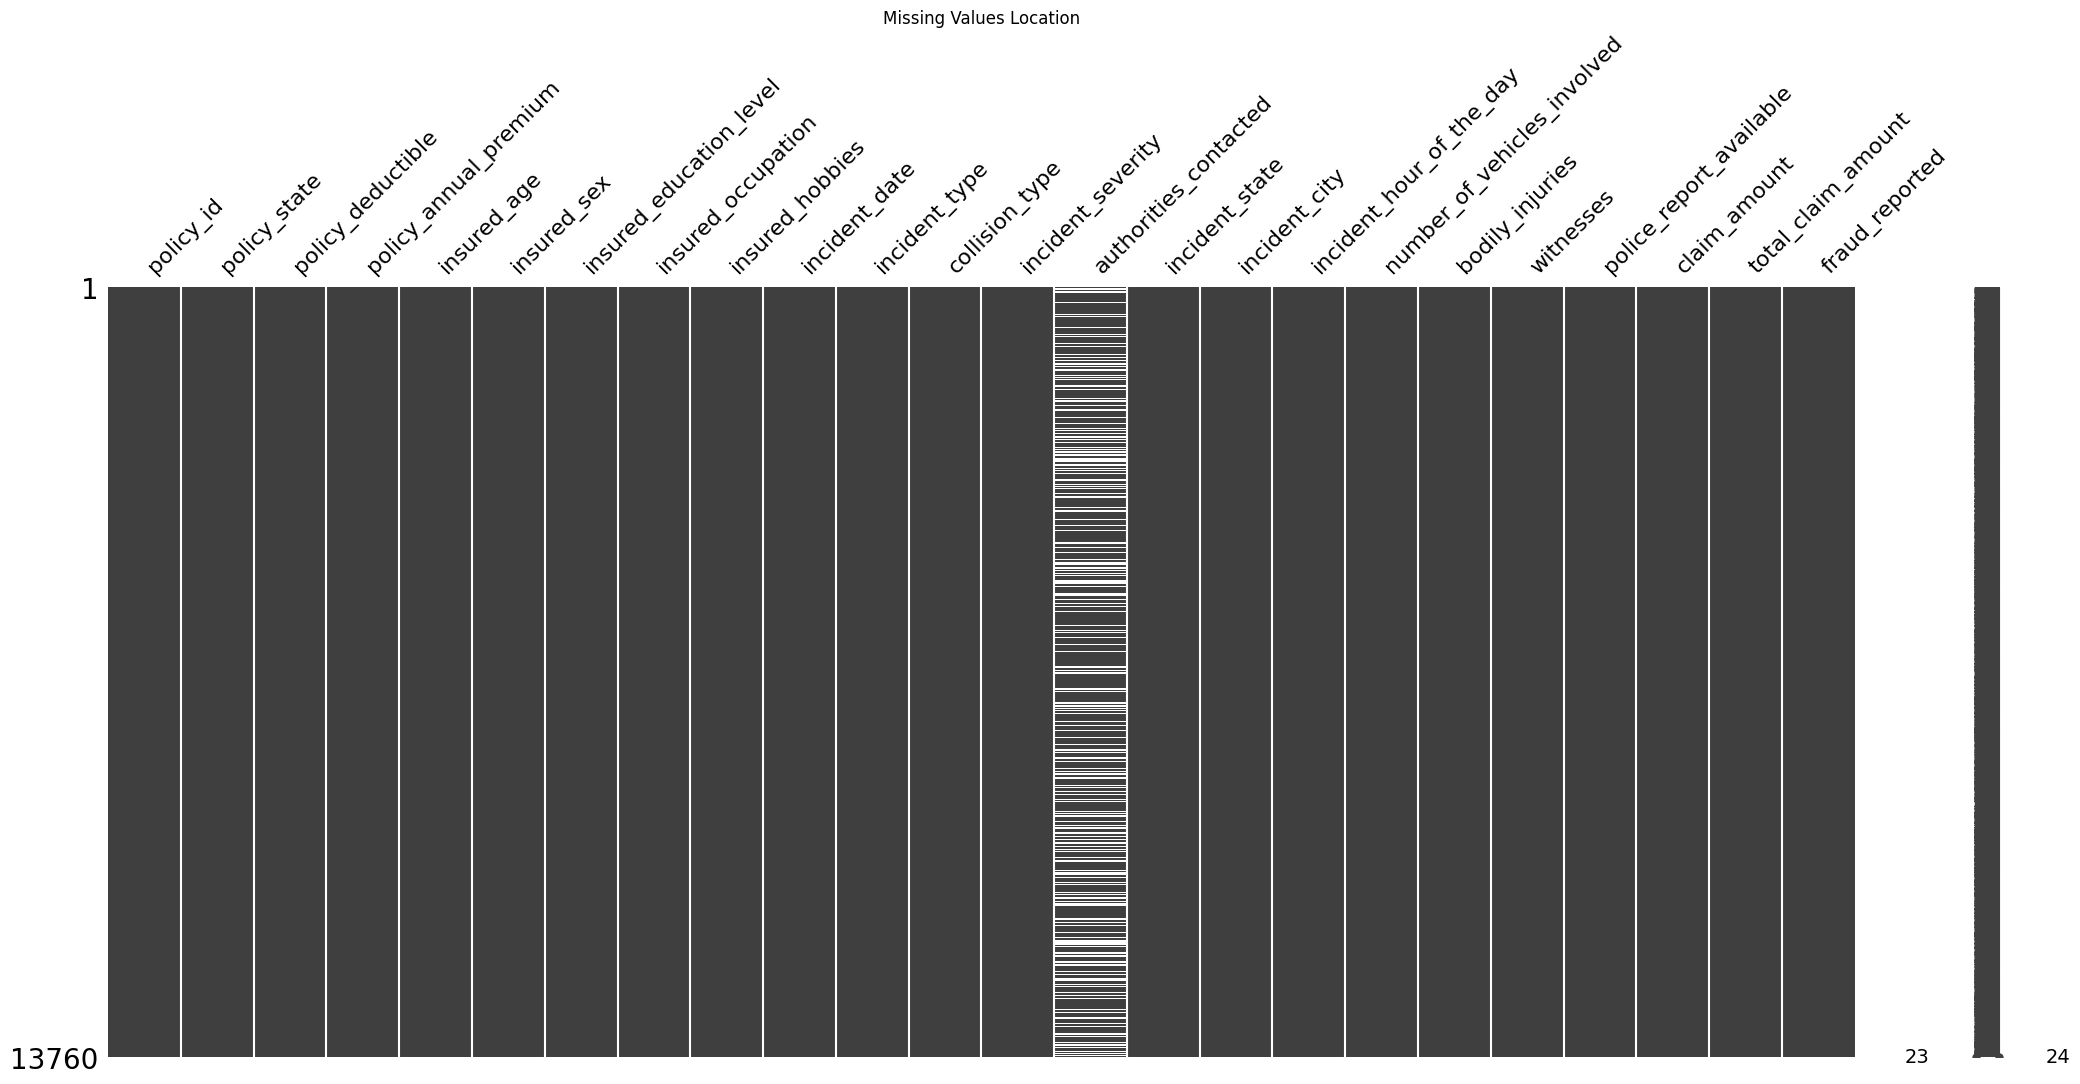

In [63]:
msno.matrix(dfAnalyse)
plt.title("Missing Values Location")
plt.show()

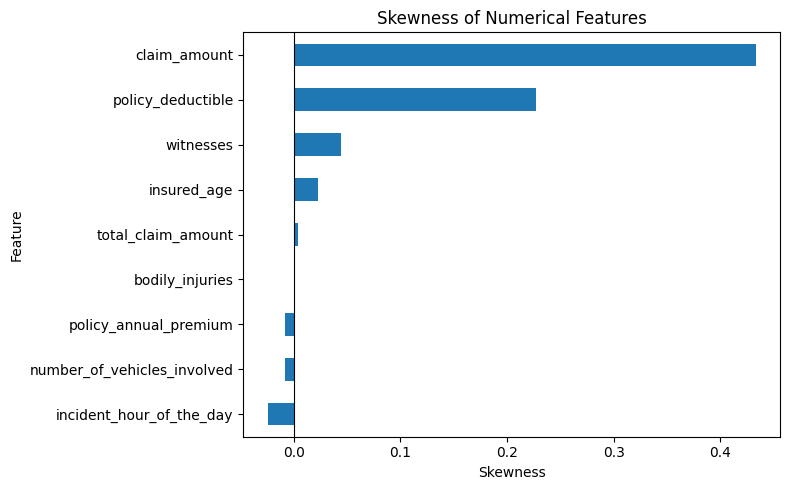

In [64]:
#Skewness analysis in numerical features
#What would benefit from scaling and what kind?

numerical_columns = dfAnalyse.select_dtypes(include=['number']).columns.tolist()

skewness = dfAnalyse[numerical_columns].skew(numeric_only=True).sort_values()

plt.figure(figsize=(8, 5))
skewness.plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

We plot the distribution of a subset of numerical features and report their skewness to visualize scale and spread\.

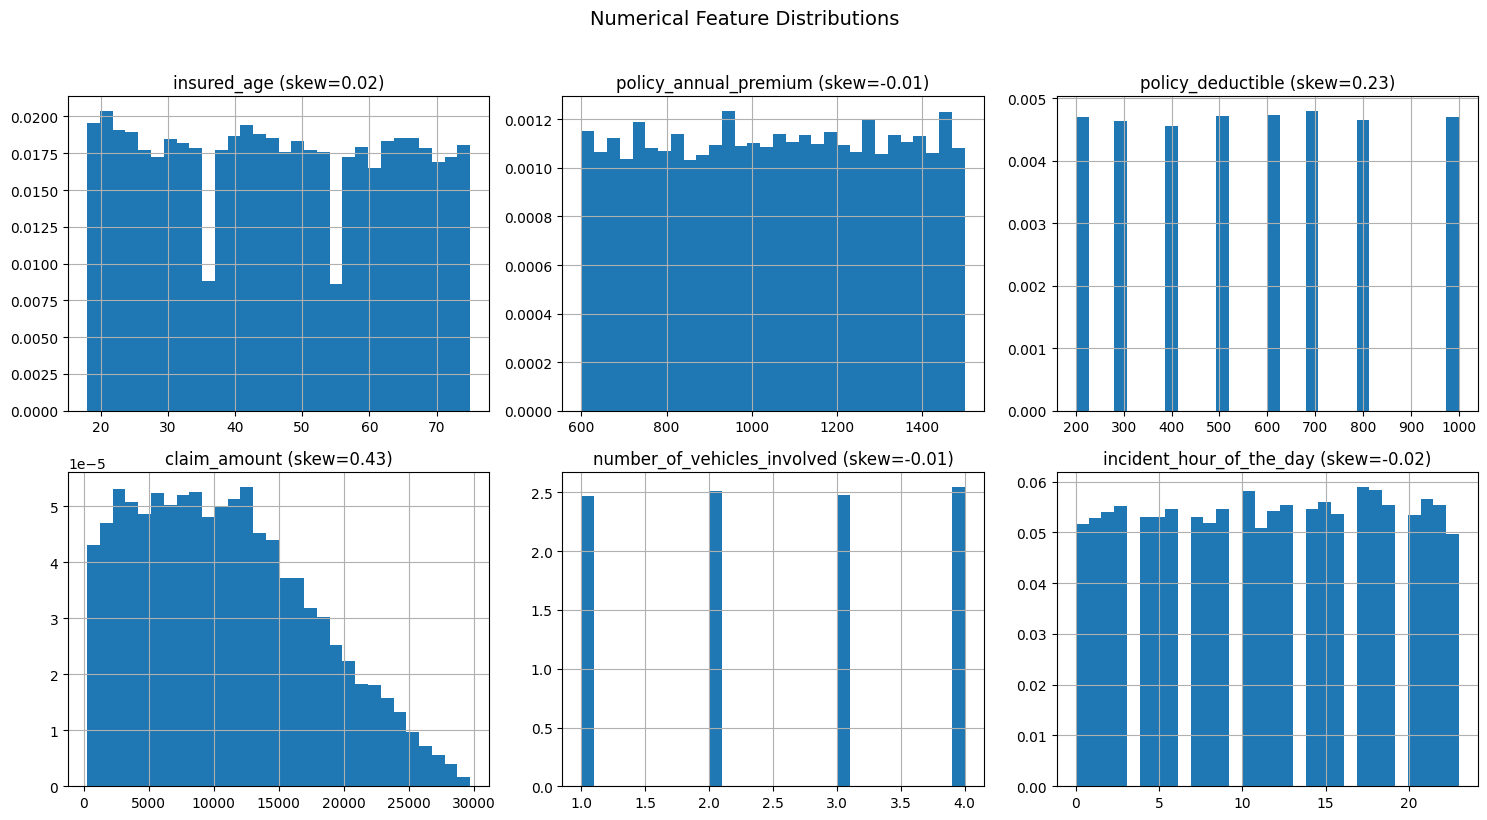

In [65]:
#Small subset of numerical features
num_cols = [
    "insured_age",
    "policy_annual_premium",
    "policy_deductible",
    "claim_amount",
    "number_of_vehicles_involved",
    "incident_hour_of_the_day",]

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, num_cols):
    data = dfAnalyse[col].dropna()
    ax.hist(data, bins=30, density=True)
    ax.set_title(f"{col} (skew={data.skew():.2f})")
    ax.grid(True)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle("Numerical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


We examine correlation via a heatmap to check for redundant/highly dependent features that might need to be removed\.

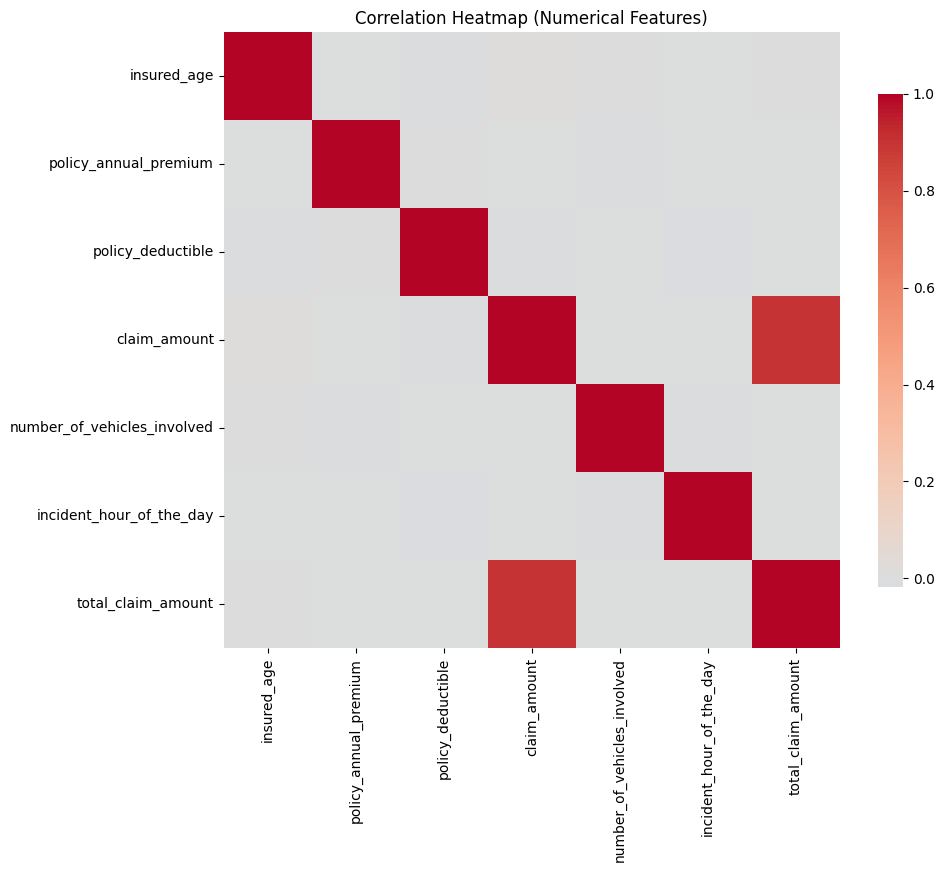

In [66]:
num_cols.append("total_claim_amount")
plt.figure(figsize=(10, 8))
Correlation = df[num_cols].corr()

sns.heatmap(
    Correlation,
    cmap = "coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

The heatmap shows that most numerical features are only weakly correlated; the exception is the strong correlation between claim\_amount and total\_claim\_amount\.

We drop total\_claim\_amount to remove this redundancy\.

## Creating the working dataset:

As required, we inject missing values into a subset of features in order to test the robustness of the preprocessing pipeline\.

This step lets us verify that the pipeline can handle incomplete inputs and that the imputation and encoding steps implemented in the ColumnTransformer are applied in the same way to training \+ test data\.

The resulting, corrupted dataset is named df\.

In [67]:
np.random.seed(42)

for col in ['police_report_available', 'insured_education_level', 'incident_state']:
    mask = np.random.rand(len(df)) < 0.1
    df.loc[mask, col] = np.nan

for col in ['insured_age', 'policy_annual_premium']:
    mask = np.random.rand(len(df)) < 0.05
    df.loc[mask, col] = np.nan

In [68]:
missingAfter = df.isna().mean().sort_values(ascending=False)
display(missingAfter[missingAfter > 0])

,0
authorities_contacted,0.287936
police_report_available,0.101453
insured_education_level,0.101381
incident_state,0.098983
insured_age,0.051090
policy_annual_premium,0.048983


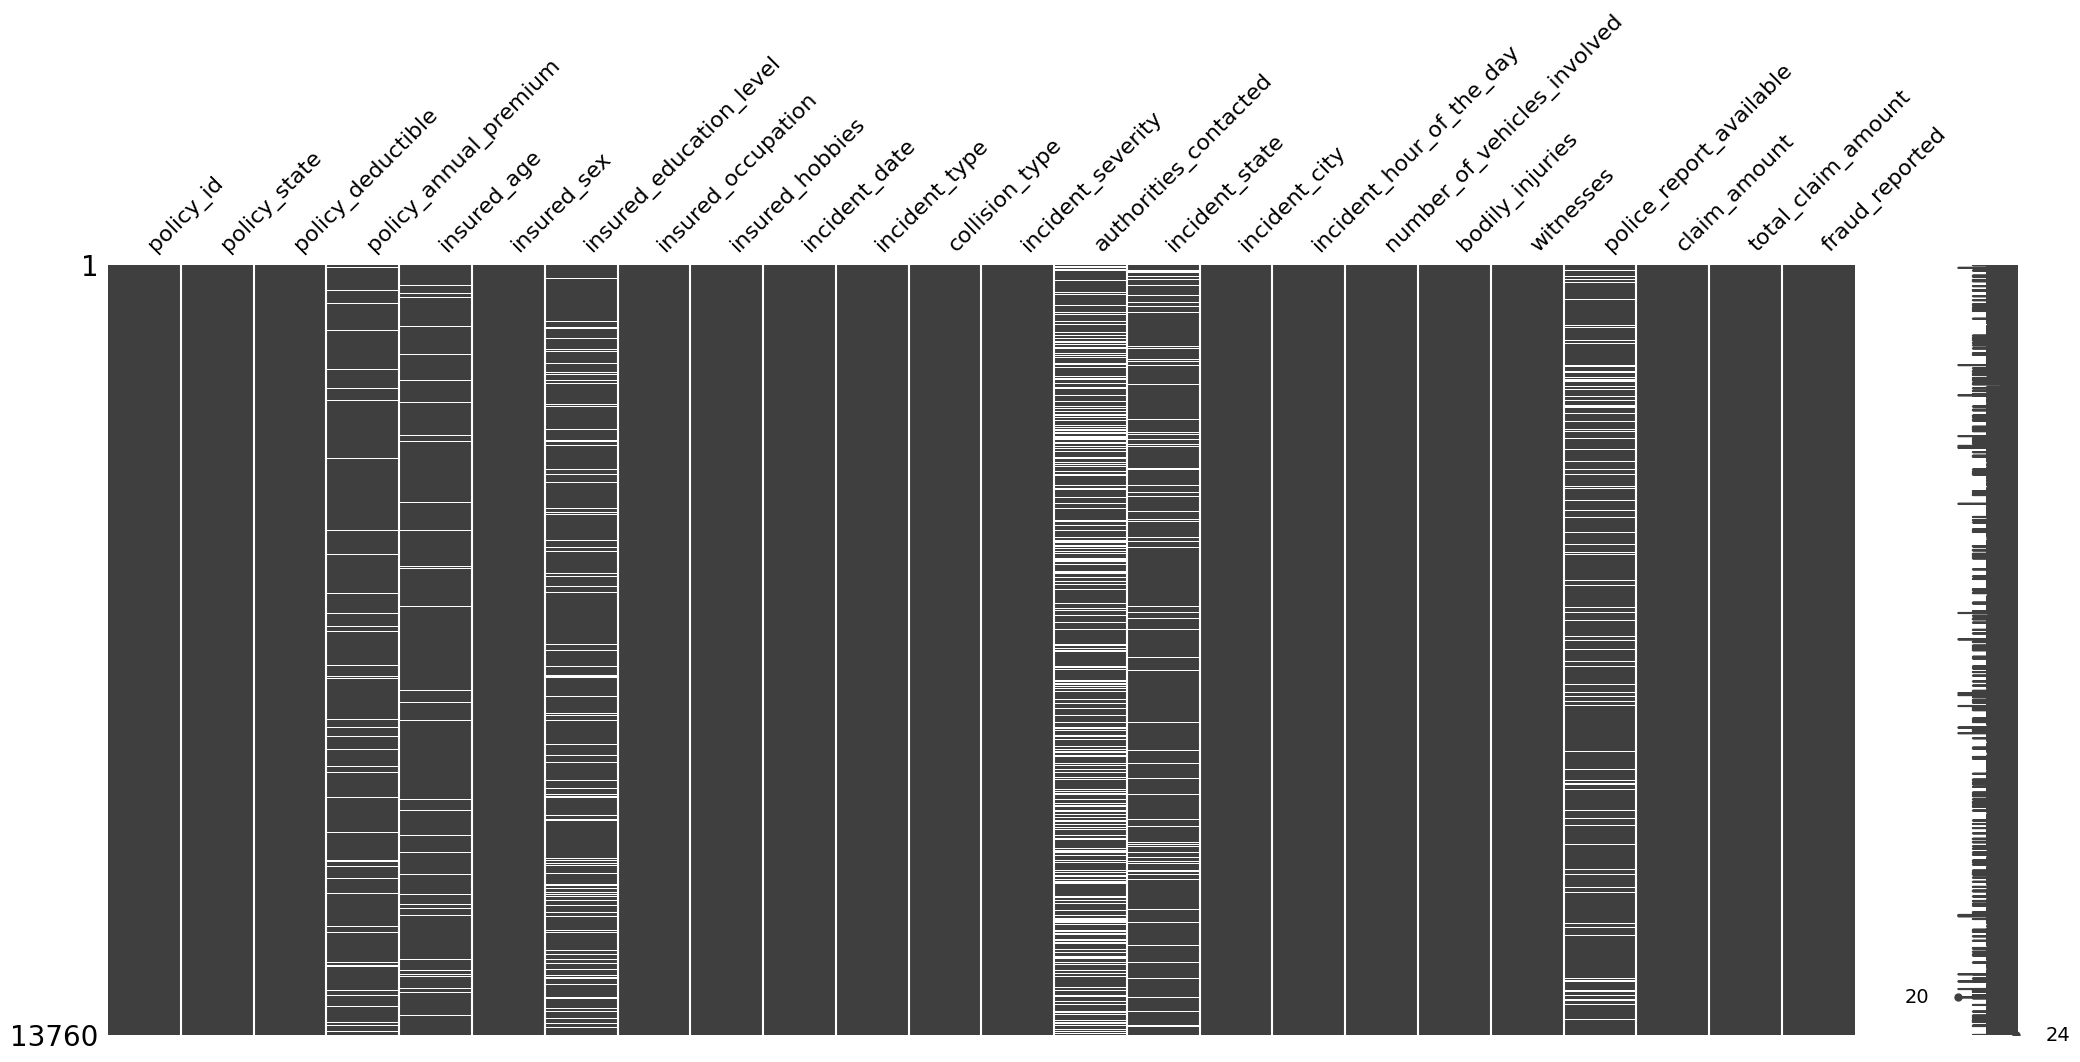

In [69]:
msno.matrix(df)
plt.show()

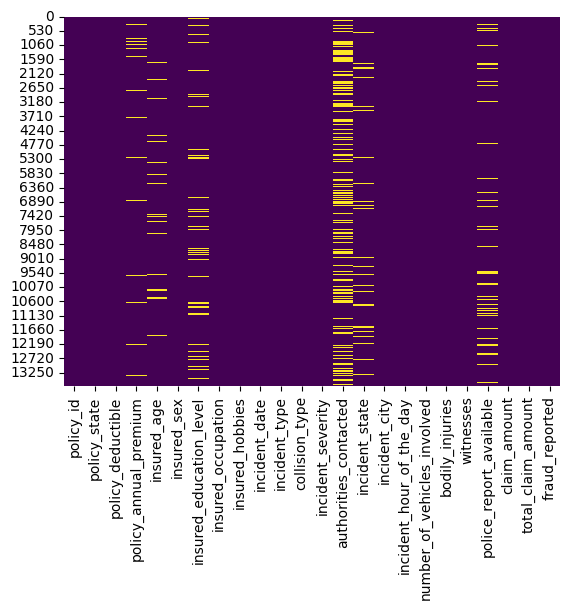

In [70]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [71]:
#Convert incident_date to datetime to make it a feature
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['incident_month'] = df['incident_date'].dt.month

#Treat missing authorities_contacted as an explicit category (authorities not contacted)
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')

## Feature selection:

Some columns have been removed because they give no predicting information or duplicate information\.
Identifiers and high\-cardinality fields are excluded to reduce dimensionality\.

In [72]:
#Uninformative, redundant or high-cardinality features dropped
cols_to_drop = [
    'policy_id',        #Unique identifier
    'incident_city',    #Too high cardinality
    'incident_date',    #Replaced by incident_month
    'total_claim_amount',  #Redundant with total_claim_amount
    'insured_hobbies',]   #High cardinality

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

#Encode target variable
y = df['fraud_reported'].map({'N': 0, 'Y': 1})

#Separate features from target
X = df.drop('fraud_reported', axis=1)

print(f"Final Features Shape: {X.shape}")
print("Columns remaining:\n" + "\n".join(X.columns))

Final Features Shape: (13760, 19)
Columns remaining:
policy_state
policy_deductible
policy_annual_premium
insured_age
insured_sex
insured_education_level
insured_occupation
incident_type
collision_type
incident_severity
authorities_contacted
incident_state
incident_hour_of_the_day
number_of_vehicles_involved
bodily_injuries
witnesses
police_report_available
claim_amount
incident_month


We put features into numerical, ordinal, and nominal categories for correct preprocessing\.
Ordinal variables are identified to keep their meaningful ordering \(e\.g\. education level\)\.
Remaining categorical variables are categorized as nominal\.

In [73]:
allNumerical = X.select_dtypes(include=['number']).columns.tolist()
numericalColumnsRobust = ['claim_amount']
numericalColumns = [col for col in allNumerical if col not in numericalColumnsRobust]
categoricalColumns = X.select_dtypes(include=["object"]).columns.tolist()
ordinalColumns = ['insured_education_level', 'incident_severity']
nominalColumns = [col for col in categoricalColumns if col not in ordinalColumns]

print(f"Numerical Features:")
print("\n".join(numericalColumns), "\n")

print(f"Skewed Numerical Features:")
print("\n".join(numericalColumnsRobust), "\n")

print(f"Ordinal Features:")
print("\n".join(ordinalColumns), "\n")

print(f"Nominal Features:")
print("\n".join(nominalColumns))

Numerical Features:
policy_deductible
policy_annual_premium
insured_age
incident_hour_of_the_day
number_of_vehicles_involved
bodily_injuries
witnesses
incident_month 

Skewed Numerical Features:
claim_amount 

Ordinal Features:
insured_education_level
incident_severity 

Nominal Features:
policy_state
insured_sex
insured_occupation
incident_type
collision_type
authorities_contacted
incident_state
police_report_available


In [74]:
#Ordinal columns
educationOrder = ['High School', 'College', 'Masters', 'PhD']
severityOrder = ['Minor Damage', 'Major Damage', 'Total Loss']

## Preprocessing pipelines:

We use type\-specific preprocessing pipelines combined in a single ColumnTransformer\.

Ordinal features: we use 'most frequent', then OrdinalEncoder to preserve the order of education \+ injury severity\.

Numerical features: we use 'median', less sensitive to outliers, and StandardScalar (on the less skewed columns) and RobustScaler (on the significantly skewed columns) so that all inputs are on a comparable scale\.

Nominal categorical: we use 'most frequent' value and OneHotEncoder to produce a sparse, purely numeric design matrix for the classifiers\.

In [75]:
ordinalTransformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OrdinalEncoder(categories=[educationOrder, severityOrder],
handle_unknown='use_encoded_value', unknown_value=-1))])

numericalTransformer = Pipeline(steps =
[('Imputer', SimpleImputer(strategy="median")),('Scaler', StandardScaler())])
#median because numerical values are a bit skewed

robustNumericalTransformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())])

nominalTransformer = Pipeline(steps =
[('imputer', SimpleImputer(strategy='most_frequent')),
('encoder', OneHotEncoder(drop = 'first', handle_unknown='ignore'))])

In [76]:
preprocessor = ColumnTransformer(transformers=[
('numerical', numericalTransformer, numericalColumns),
('numericalRobust', robustNumericalTransformer, numericalColumnsRobust),
('nominal', nominalTransformer, nominalColumns),
('ordinal', ordinalTransformer, ordinalColumns)],
 verbose_feature_names_out= False, sparse_threshold=0,)

## Training / test split:

We split df into 80% training and 20% test data using train\_test\_split with stratification on the target to keep the class distribution\.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2,
    stratify = y,
    random_state = 30, shuffle = True)

In [78]:
#Inspect feature space expansion after preprocessing
X_transformed = preprocessor.fit_transform(X_train)

print(f"Original columns: {X_train.shape[1]}")
print(f"Columns after Encoding: {X_transformed.shape[1]}")

Original columns: 19
Columns after Encoding: 48


## Model selection:


The following model pipeline has four steps: preprocessing, class rebalancing, dimensionality reduction, and classification\.
All transformations are wrapped in a single pipeline so that cross\-validation always fits them only on the training folds\.

Class imbalance: based on the target distribution of fraud\_reported, the minority class is quite less frequent, so we include several resampling options in the search: no sampling, over\-sampling \(RandomOverSampler, SMOTE\) and under\-sampling \(RandomUnderSampler\)\.

Dimensionality reduction: after preprocessing \(and possible resampling\), an optional PCA step is used\.
One\-hot encoding creates a high dimensional feature space, and PCA allows us to test whether projecting onto a lower dimensional space helps by removing redundancy and noise\. PCA is not forced however: the hyperparameter search includes both no PCA and several variance thresholds\.

Classifier: we choose from several standard models: Perceptron, KNN, Random Forest, and Logistic Regression\.
For each of these we tune a set of hyperparameters\. This joint search over sampler, optional PCA and classifier lets the nested cross\-validation procedure automatically select a great combination for this particular dataset\.

In [79]:
model_pipeline= IMBPipeline([('preprocessor', preprocessor),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA()),
    ('classifier', LogisticRegression())])

We follow the 'urns' strategy from the hyperparameter\-tuning lecture: for each part of the pipeline we define a small set of candidate configurations\.

We then take the cartesian product of these three sets to obtain all\_configs, a list of dictionaries where each element defines one complete pipeline configuration \(which sampler, whether to use PCA and with which n\_components, and which classifier with its hyperparameters\)\.

In [80]:
sampler_configs = [{"sampler": [None]},
    {"sampler": [SMOTE(random_state=42)],
     "sampler__sampling_strategy": ["minority", 0.7, 0.9, 1.0],},
    {"sampler": [RandomOverSampler(random_state=42)],
     "sampler__sampling_strategy": ["minority", 0.5, 0.7, 0.9],},
    {"sampler": [RandomUnderSampler(random_state=42)],
     "sampler__sampling_strategy": ["majority", 0.5, 0.7, 0.9],},]

dim_reduction_configs = [{"dim_reduction": [None]},
    {"dim_reduction": [PCA()],
     "dim_reduction__n_components": [0.5, 0.7, 0.9],},]

classifier_configs = [{
        "classifier": [Perceptron(random_state=42)],
        "classifier__eta0": loguniform(0.001, 100),
        "classifier__max_iter": [500, 1000, 2000],
        "classifier__class_weight": [None, "balanced"],},
    {
        "classifier": [KNeighborsClassifier()],
        "classifier__n_neighbors": [3, 5, 7, 9],},
    {
        "classifier": [RandomForestClassifier(random_state=42, n_jobs=-1)],
        "classifier__n_estimators": [10, 50, 100, 500],
        "classifier__class_weight": [None, "balanced"],},
    {
        "classifier": [LogisticRegression(solver="saga", random_state=42)],
        "classifier__C": loguniform(0.001, 100),
        "classifier__penalty": ["l1", "l2"],
        "classifier__class_weight": [None, "balanced"],},]

In [81]:
all_configs = [
    dict(itertools.chain(*(e.items()
    for e in configuration)))
    for configuration in itertools.product(sampler_configs,
    dim_reduction_configs, classifier_configs)]

f'Number of all possible configurations: {len(all_configs)}'

'Number of all possible configurations: 32'

In the inner loop we use a RandomizedSearchCV object\.
The estimator is the full pipeline and param\_distributions is set to the list of pipeline configurations all\_configs\.
We use 3\-fold cross\-validation inside this search and the F1\-score as the evaluation metric \(also we will also show balanced\_acc later\.\)

In [82]:
rs = RandomizedSearchCV(model_pipeline,
param_distributions=all_configs,n_iter=len(all_configs),
n_jobs=-1, cv = 3, scoring='f1')

To evaluate the whole model\-selection procedure, we wrap this RandomizedSearchCV in an outer 5\-fold cross\-validation using cross\_validate\. In each outer fold, the inner search performs its own 3\-fold CV on the training part of that fold to choose the best pipeline configuration\.
The outer fold score is then the F1\-score obtained on the held\-out validation part\.

By setting return\_estimator=True we keep the best pipeline found in each outer fold, which we later inspect to see which sampler/PCA/classifier combinations are preferred across folds\.

In [ ]:
scores = cross_validate(rs, X_train, y_train,
scoring='f1', cv = 5, return_estimator=True, verbose=3)

[CV] END ......................................., score=0.528 total time=  51.4s
[CV] END ......................................., score=0.517 total time= 1.1min
[CV] END ......................................., score=0.459 total time= 1.1min


We refit the RandomizedSearchCV object on the full training set \(X\_train, y\_train\)\.

This re\-runs the inner 3\-fold CV on all available training data and chooses the single best pipeline according to the cross\-validated F1\-score\.

The resulting best estimator is a pipeline with preprocessing, RandomUnderSampler and Random Forest\.

In [ ]:
rs.fit(X_train, y_train)

The nested cross\-validation procedure selects a RandomForest pipeline with a mean F1 of about 0\.5 across the inner/outer folds\.

We report F1 and balanced accuracy instead of plain accuracy\. On this dataset a classifier that almost always predicts “non\-fraud” might achieve a high plain accuracy while doing a bad job on the minority fraud class\.

F1 focuses on the fraud class by considering both precision and recall, so it gives a higher score on models that both finds many fraudulent claims and keep the number of false alarms under control\.

Balanced accuracy averages the performance on the fraud and non\-fraud classes, giving them equal importance regardless of how frequent they are, which makes the score around 0\.7 informative\.

In [ ]:
#Best cross-validated performance
print("\nBest CV F1:", rs.best_score_)
print("Best params:\n", rs.best_params_)

#Apply best model
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
print("Test F1:", f1_score(y_test, y_pred))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, y_pred))

In [ ]:
print("\nTest-set report:")
print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

In [ ]:
ConfusionNormalised = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=ConfusionNormalised,display_labels=np.unique(y_test))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title('Normalized Confusion Matrix')
plt.show()

To evaluate the model beyond a single threshold, we also plot the ROC and Precision–Recall curves on the test set\.

In [ ]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve (Best Model)")
plt.show()

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Precision–Recall Curve (Best Model)")
plt.show()

We inspect the best model chosen in each outer fold\.
The loop below prints for every fold the sampler that was selected, the classifier with its main hyperparameters, and the corresponding F1 score\.

In [ ]:
for index, estimator in enumerate(scores['estimator']):

    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['classifier'],
    estimator.best_estimator_.get_params()['classifier'].get_params())

    print(scores['test_score'][index])
    print('-'*10)

Do the selected models overfit?

We compare the F1 scores of the training part of each outer fold with the F1 scores on the corresponding validation part\.

In [ ]:
for estimator in scores['estimator']:

    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)

    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)

    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

There is clear overfitting: the RandomForest gets higher F1 on the training folds than on validation/test\.
We will address this issue in the following steps, where depth and leaf parameters will be tuned.

## Model refinement:

Random Forest achieved the overall highest F1 score, so it was chosen for model refinement\.

In [ ]:
best_model_pipeline = IMBPipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=42, sampling_strategy=0.9)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])

For RandomForest we tune a small set of standard hyperparameters that control the model’s complecxity and how it handles class imbalance\.

The grid below varies the number and depth of trees, how many samples are needed to split/keep a leaf, which feature subset is used at each split, and whether to use class weights\.

In [ ]:
params = {
    #number of trees in the forest
    'classifier__n_estimators': [100, 200, 300],
    #limit tree depth vs fully grown trees
    'classifier__max_depth': [4, 6, 8],
    #minimum samples to split a node
    'classifier__min_samples_split': [5, 10,20],
    'classifier__min_samples_leaf': [5, 10, 20],
    #minority class out weighted
    'classifier__class_weight': [None, 'balanced']}

The object rs\_best\.best\_estimator is the final tuned pipeline that will be evaluated on the test set\.

In [ ]:
rs_best = RandomizedSearchCV(estimator=best_model_pipeline, param_distributions=params,
    cv=3, n_iter=10, scoring='f1', n_jobs=-1, random_state=42)

rs_best.fit(X_train, y_train)

rs_best.best_estimator_

In [ ]:
#F1-score on test set
#true labels vs predicted labels from best tuned model
f1_score(y_test, rs_best.best_estimator_.predict(X_test))

We use a learning curve to analyse the behavior of the tuned RandomForest\.

We vary the training set size of the available training data and compute F1 with 3\-fold cross\-validation\.

In [ ]:
cls = rs_best.best_estimator_

#Vary training size to analyze bias + variance behavior
#5 fold with F1 for scoring
train_sizes, train_scores, test_scores = learning_curve(cls,
    X=X_train, y=y_train, train_sizes=[0.1, 0.3, 0.5, 0.8, 1.0], cv=3,
    n_jobs=-1, scoring='f1', shuffle=False)

In [ ]:
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean, color='blue', marker='+', markersize=5, label='Training F1')
ax.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean, color='green', linestyle='--', marker='d', markersize=5, label='Validation F1')
ax.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

plt.show()


The plot shows that training F1 starts very high and decreases as more data is used, while validation F1 increases and then stabilises; the gap between the two curves decreases but doesn't disappear\.

In [ ]:
#range of number of trees to evaluate
range_n_estimators = [50, 100, 200, 400, 800]

train_scores, test_scores = validation_curve(cls, X=X_train, y=y_train, param_range=range_n_estimators,
    param_name='classifier__n_estimators', cv=5, n_jobs=-1,scoring='f1')

In [ ]:
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(range_n_estimators, train_mean,
        color='blue', marker='o',
        markersize=5, label='Training F1')
ax.fill_between(range_n_estimators,
                train_mean + train_std,
                train_mean - train_std,
                alpha=0.15, color='blue')

ax.plot(range_n_estimators, test_mean,
        color='green', linestyle='--',
        marker='s', markersize=5,
        label='Validation F1')
ax.fill_between(range_n_estimators,
                test_mean + test_std,
                test_mean - test_std,
                alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

plt.show()


The plot shows that validation F1 decreases only slightly while training F1 is almost flat\.

This tells us that increasing the number of trees does not lead to severe overfitting, and also gives very limited additional benefit\.

## Conclusion:

To briefly summarise the above project: we built a supervised learning pipeline for detecting fraud,
 following the course structure: feature preprocessing \(ColumnTransformer\), injecting and handling
 missing values, tackling class imbalance, resampling\.

Comparing models, RandomForest was the best candidate and we tuned in further with a cross\-validated
 random search\.

Final model: RandomUnderSampler and RandomForest, with a result on the F1 score of about 0\.5, and
 a balanced accuracy of roughly 0\.7\.

ROC and Precision Recall confirmed that the model can rank fraudulent claims above non fraudulent
 ones but precision is difficult given the imbalance between frauds and non frauds\.

The learning and validation curves did show some overfitting on small samples but
decent bias variance trade\-off overall\.